In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import argparse
import pandas as pd
import numpy as np
import importlib
import tfsplt_future_past_utils as pu

In [2]:
# define parameters
class Args(argparse.Namespace):

    rois = ["IFG","MTG", "STG","preCG","postCG", "rostralmiddlefrontal",
        "superiorfrontal", "supramarginal", "ITG", "TP", "fusiform", "All"]
    # rois = ["IFG","STG","preCG","postCG","TP","dSM","mSM","vSM", "All"]    
    
    # NOTE: lines must match the label3 values in the data (standardized without _banded_ prefix)
    lines = ["joint", "word", "sentence", "sentence2"] # line id
    # colors = ["green", "grey", "orange", "red", "black", "purple"]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    legends = ["joint", "word", "future", "past"]

    lags = {
            "lags_all": np.arange(-2000, 2001, 50),
            "lags_plt": np.arange(-2000, 2001, 50), # selected subset
            "lag_ticks": np.arange(-2000, 2001, 500), # this and next one need to have same number of elements
            "lag_tick_labels": np.arange(-2, 2.001, 0.5), # this and previous one need to have same number of elements
        }
    res_dir = '/scratch/gpfs/gidon/247-plotting/results/figures'

In [3]:
args = Args()
all_elecs = pd.read_csv("/scratch/gpfs/HASSON/kw1166/247/247-plotting/data/plotting/paper-sts/base_df.csv")
thresh_single = None 
res_d = "/scratch/gpfs/HASSON/gidon/247-encoding-dev/results/tfs"
res_d_itamar = "/scratch/gpfs/HASSON/ij9216/projects/code/247/247-encoding-dev/results/tfs"

# For plotting, we want to align all results to the same lag window (ms).
# This avoids fragile iloc-based indexing when different result files have different lag grids.
LAG_MIN, LAG_MAX = -2000, 2000

# Pick up any edits to the utils module without restarting the kernel.
importlib.reload(pu)

#Original, trained
original8_c = pu.load_res_add_roi_threshold(f"{res_d_itamar}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context8_comp.csv", thresh_single)
original8_p = pu.load_res_add_roi_threshold(f"{res_d_itamar}/ij-tfs-%s-gpt2-xl-bandedRidge-lag30k-50-all-static_future_past-noreph_pca300_30s_context8_prod.csv", thresh_single)
print(f"Loaded original sentences: {len(original8_c)} comprehension, {len(original8_p)} production electrodes")
original8_c = pu.select_lag_range_and_last_columns(original8_c, LAG_MIN, LAG_MAX)
original8_p = pu.select_lag_range_and_last_columns(original8_p, LAG_MIN, LAG_MAX)

#Random content word
random_content_word8_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_comp.csv", thresh_single)
random_content_word8_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_prod.csv", thresh_single)
print(f"Loaded random content word sentences: {len(random_content_word8_c)} comprehension, {len(random_content_word8_p)} production electrodes")
random_content_word8_c = pu.select_lag_range_and_last_columns(random_content_word8_c, LAG_MIN, LAG_MAX)
random_content_word8_p = pu.select_lag_range_and_last_columns(random_content_word8_p, LAG_MIN, LAG_MAX)
random_content_word8_c['label3'] = random_content_word8_c['label3'].str.replace('_banded_', '', regex=False)
random_content_word8_p['label3'] = random_content_word8_p['label3'].str.replace('_banded_', '', regex=False)

#Paraphrase
paraphrase8_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_comp.csv", thresh_single)
paraphrase8_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_prod.csv", thresh_single)
print(f"Loaded paraphrase sentences: {len(paraphrase8_c)} comprehension, {len(paraphrase8_p)} production electrodes")
paraphrase8_c = pu.select_lag_range_and_last_columns(paraphrase8_c, LAG_MIN, LAG_MAX)
paraphrase8_p = pu.select_lag_range_and_last_columns(paraphrase8_p, LAG_MIN, LAG_MAX)
paraphrase8_c['label3'] = paraphrase8_c['label3'].str.replace('_banded_', '', regex=False)
paraphrase8_p['label3'] = paraphrase8_p['label3'].str.replace('_banded_', '', regex=False)

#Paraphrase random content
parandom8_c = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_rephrased_random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_comp.csv", thresh_single)
parandom8_p = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-paraphrase_rephrased_random_content_words_pca300_drop-short_mistral_trained_rephrased_sentence_cnxt_0008_prod.csv", thresh_single)
print(f"Loaded paraphrase rephrased random content sentences: {len(parandom8_c)} comprehension, {len(parandom8_p)} production electrodes")
parandom8_c = pu.select_lag_range_and_last_columns(parandom8_c, LAG_MIN, LAG_MAX)
parandom8_p = pu.select_lag_range_and_last_columns(parandom8_p, LAG_MIN, LAG_MAX)
parandom8_c['label3'] = parandom8_c['label3'].str.replace('_banded_', '', regex=False)
parandom8_p['label3'] = parandom8_p['label3'].str.replace('_banded_', '', regex=False)

# Randomly rephrased sentences, untrained model
untr_reph_c8 = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph_rand-m-diff-w-2_pca300_drop-short_mistral_untrained_rephrased_sentence_cnxt_0008_comp.csv", thresh_single)
untr_reph_p8 = pu.load_res_add_roi_threshold(f"{res_d}/gp-tfs-%s-gpt2-xl-bandedRidge-lag60-50-all-static_future_past-reph_rand-m-diff-w-2_pca300_drop-short_mistral_untrained_rephrased_sentence_cnxt_0008_prod.csv", thresh_single)
print(f"Loaded untrained, randomly rephrased sentences: {len(untr_reph_c8)} comprehension, {len(untr_reph_p8)} production electrodes")
untr_reph_c8 = pu.select_lag_range_and_last_columns(untr_reph_c8, LAG_MIN, LAG_MAX)
untr_reph_p8 = pu.select_lag_range_and_last_columns(untr_reph_p8, LAG_MIN, LAG_MAX)
untr_reph_c8['label3'] = untr_reph_c8['label3'].str.replace('_banded_', '', regex=False)
untr_reph_p8['label3'] = untr_reph_p8['label3'].str.replace('_banded_', '', regex=False)

df_list_c = [original8_c, random_content_word8_c, paraphrase8_c, parandom8_c, untr_reph_c8]
df_list_p = [original8_p, random_content_word8_p, paraphrase8_p, parandom8_p, untr_reph_p8]

titles = ["original", "random content", "paraphrase", "paraphrase random content", "untrained_random"]

Loaded original sentences: 2644 comprehension, 2648 production electrodes
Loaded random content word sentences: 2640 comprehension, 2636 production electrodes
Loaded paraphrase sentences: 2644 comprehension, 2648 production electrodes
Loaded paraphrase rephrased random content sentences: 2636 comprehension, 2628 production electrodes
Loaded untrained, randomly rephrased sentences: 2531 comprehension, 2530 production electrodes


In [4]:
# Back to original electrode selection approach (using electrode names)
shared_electrodes_c, filtered_dfs_c, roi_results_c = pu.process_shared_electrodes_roi(
    df_list_c,
    args.rois,
    OR_thresh=0.1
)
shared_electrodes_p, filtered_dfs_p, roi_results_p = pu.process_shared_electrodes_roi(
    df_list_p,
    args.rois,
    OR_thresh=0.1
)

print(f"Comprehension: {len(shared_electrodes_c)} shared electrodes")
print(f"Production: {len(shared_electrodes_p)} shared electrodes")

# Now identify which of these shared electrodes appear in multiple subjects
# and create a plotting list that splits them
def create_plotting_list(shared_electrodes, df_list):
    """
    Create list of (subject, electrode) tuples for plotting.
    For electrodes in multiple subjects, create separate entries.
    For single-subject electrodes, create one entry with subject=None (to flag it's single-subject).
    """
    # First, collect all (subject, electrode) pairs that exist in ALL dataframes
    pair_sets = []
    for df in df_list:
        joint_data = df[df['label3'] == 'joint']
        # Only consider electrodes in our shared set
        joint_data = joint_data[joint_data['electrode'].isin(shared_electrodes)]
        pairs = set(zip(joint_data['subject'], joint_data['electrode']))
        pair_sets.append(pairs)
    
    shared_pairs = set.intersection(*pair_sets)
    
    # Group by electrode to see which are multi-subject
    from collections import defaultdict
    electrode_subjects = defaultdict(list)
    for subject, electrode in shared_pairs:
        electrode_subjects[electrode].append(subject)
    
    # Create plotting list
    plotting_list = []
    for electrode in sorted(shared_electrodes):
        subjects = electrode_subjects.get(electrode, [])
        if len(subjects) > 1:
            # Multi-subject: create separate entries
            for subject in sorted(subjects):
                plotting_list.append((subject, electrode))
        elif len(subjects) == 1:
            # Single subject: mark with (subject, electrode)
            plotting_list.append((subjects[0], electrode))
        # If len(subjects) == 0, electrode is not in shared_pairs, skip it
    
    return plotting_list, electrode_subjects

plotting_list_c, electrode_subjects_c = create_plotting_list(shared_electrodes_c, df_list_c)
plotting_list_p, electrode_subjects_p = create_plotting_list(shared_electrodes_p, df_list_p)

# Count multi-subject cases
multi_c = sum(1 for e, subs in electrode_subjects_c.items() if len(subs) > 1)
multi_p = sum(1 for e, subs in electrode_subjects_p.items() if len(subs) > 1)

print(f"\nComprehension: {len(plotting_list_c)} plots ({multi_c} electrode names in multiple subjects)")
print(f"Production: {len(plotting_list_p)} plots ({multi_p} electrode names in multiple subjects)")

Comprehension: 313 shared electrodes
Production: 287 shared electrodes

Comprehension: 316 plots (6 electrode names in multiple subjects)
Production: 296 plots (14 electrode names in multiple subjects)


In [5]:
# Diagnostic: Show multi-subject electrode details
print("Multi-Subject Electrode Summary")
print("="*80)

print("\nComprehension:")
print(f"  Total shared electrodes: {len(shared_electrodes_c)}")
print(f"  Multi-subject electrodes: {sum(1 for e, subs in electrode_subjects_c.items() if len(subs) > 1)}")
print(f"  Total plots (with splits): {len(plotting_list_c)}")

multi_c = [(e, subs) for e, subs in electrode_subjects_c.items() if len(subs) > 1]
if multi_c:
    print("\n  Multi-subject electrode details:")
    for electrode, subjects in sorted(multi_c):
        print(f"    {electrode}: {sorted(subjects)}")

print("\n" + "-"*80)
print("\nProduction:")
print(f"  Total shared electrodes: {len(shared_electrodes_p)}")
print(f"  Multi-subject electrodes: {sum(1 for e, subs in electrode_subjects_p.items() if len(subs) > 1)}")
print(f"  Total plots (with splits): {len(plotting_list_p)}")

multi_p = [(e, subs) for e, subs in electrode_subjects_p.items() if len(subs) > 1]
if multi_p:
    print("\n  Multi-subject electrode details:")
    for electrode, subjects in sorted(multi_p):
        print(f"    {electrode}: {sorted(subjects)}")

Multi-Subject Electrode Summary

Comprehension:
  Total shared electrodes: 313
  Multi-subject electrodes: 6
  Total plots (with splits): 316

  Multi-subject electrode details:
    EEGAT_01REF: [625, 676]
    EEGAT_02REF: [625, 676]
    EEGAT_03REF: [625, 676]
    EEGAT_04REF: [625, 676]
    EEGDAMT_08REF: [625, 676]
    EEGDPMT_04REF: [625, 676]

--------------------------------------------------------------------------------

Production:
  Total shared electrodes: 287
  Multi-subject electrodes: 14
  Total plots (with splits): 296

  Multi-subject electrode details:
    EEGAT_01REF: [625, 676]
    EEGAT_02REF: [625, 676]
    EEGAT_03REF: [625, 676]
    EEGAT_04REF: [625, 676]
    EEGDAMT_01REF: [625, 676]
    EEGDAMT_04REF: [625, 676]
    EEGDAMT_05REF: [625, 676]
    EEGDAMT_06REF: [625, 676]
    EEGDAMT_07REF: [625, 676]
    EEGDAMT_08REF: [625, 676]
    EEGDPMT_03REF: [625, 676]
    EEGDPMT_04REF: [625, 676]
    EEGDPMT_05REF: [625, 676]
    EEGDPMT_07REF: [625, 676]


In [8]:
# Diagnostic: Check column structure
print("Checking column structure for first electrode...")
print("="*80)

# Check comprehension data
test_df = original8_c
first_electrode = test_df[test_df['label3'] == 'joint'].iloc[0]

print(f"\nTotal columns: {len(test_df.columns)}")
print(f"\nFirst 10 columns: {list(test_df.columns[:10])}")
print(f"\nLast 10 columns: {list(test_df.columns[-10:])}")

# Check what columns would be selected with [:-5]
lag_cols_position = test_df.columns[:-5]
print(f"\nUsing [:-5] would give {len(lag_cols_position)} columns")
print(f"First few: {list(lag_cols_position[:5])}")
print(f"Last few: {list(lag_cols_position[-5:])}")

# Check what columns would be selected by name filtering
lag_cols_name = [col for col in test_df.columns 
                 if col not in ['subject', 'electrode', 'label3', 'label1', 'roi']]
print(f"\nFiltering by name would give {len(lag_cols_name)} columns")
print(f"First few: {lag_cols_name[:5]}")
print(f"Last few: {lag_cols_name[-5:]}")

Checking column structure for first electrode...

Total columns: 86

First 10 columns: ['560', '561', '562', '563', '564', '565', '566', '567', '568', '569']

Last 10 columns: ['636', '637', '638', '639', '640', 'subject', 'electrode', 'label3', 'label1', 'roi']

Using [:-5] would give 81 columns
First few: ['560', '561', '562', '563', '564']
Last few: ['636', '637', '638', '639', '640']

Filtering by name would give 81 columns
First few: ['560', '561', '562', '563', '564']
Last few: ['636', '637', '638', '639', '640']


Plotting 316 comprehension electrodes to PDF...
  Saved 10/316 plots...


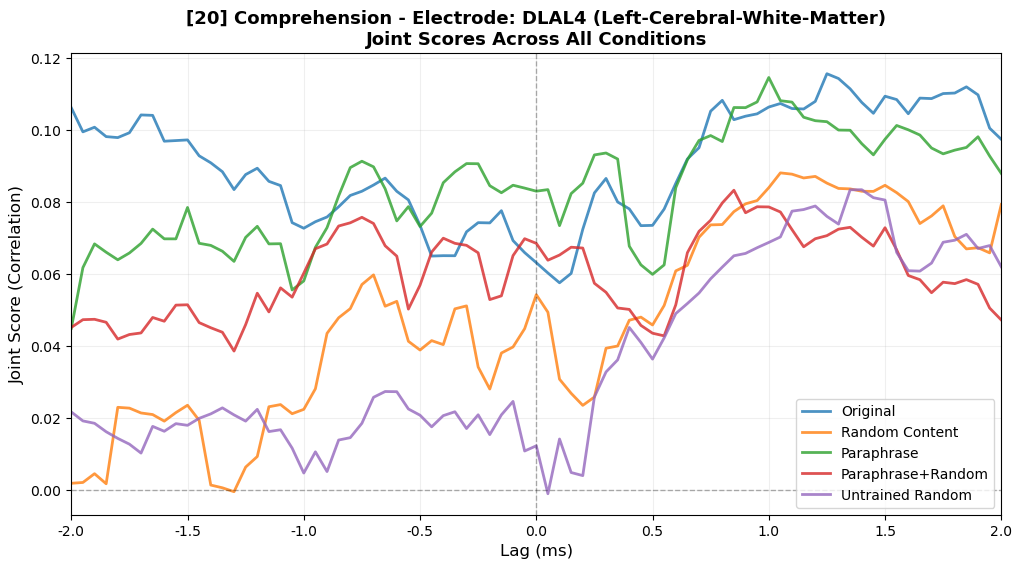

  Saved 20/316 plots...
  Saved 30/316 plots...


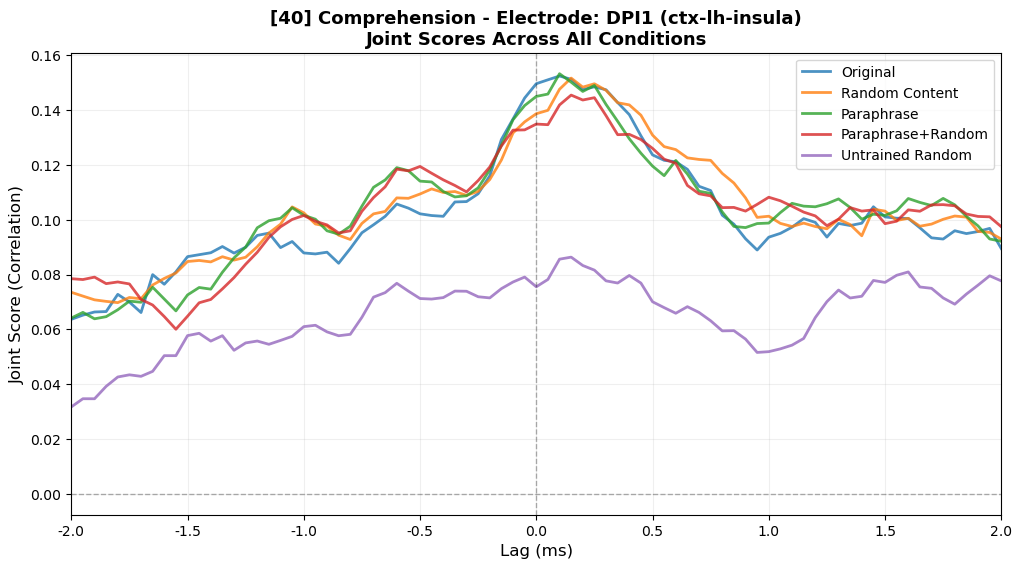

  Saved 40/316 plots...
  Saved 50/316 plots...


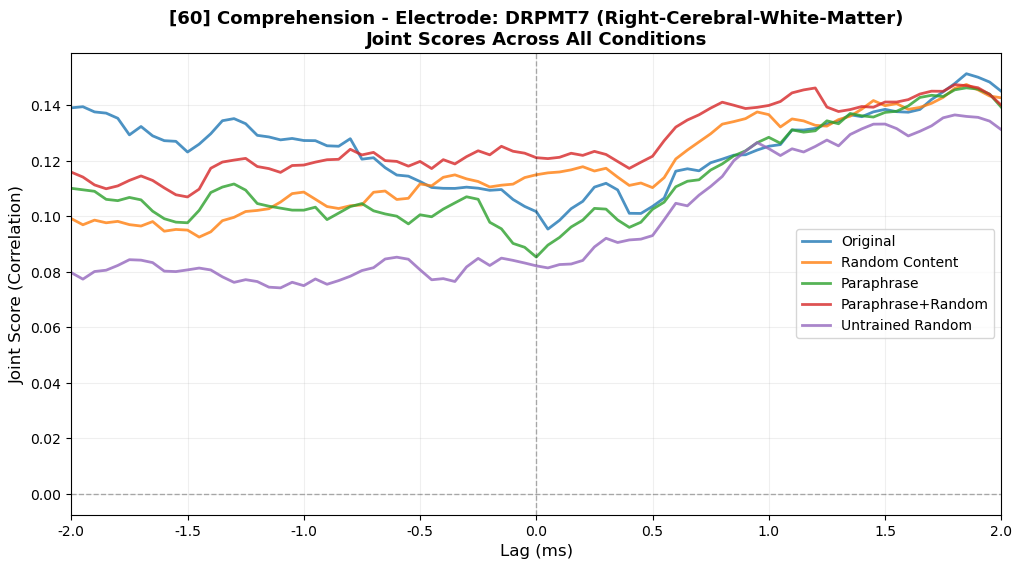

  Saved 60/316 plots...
  Saved 70/316 plots...


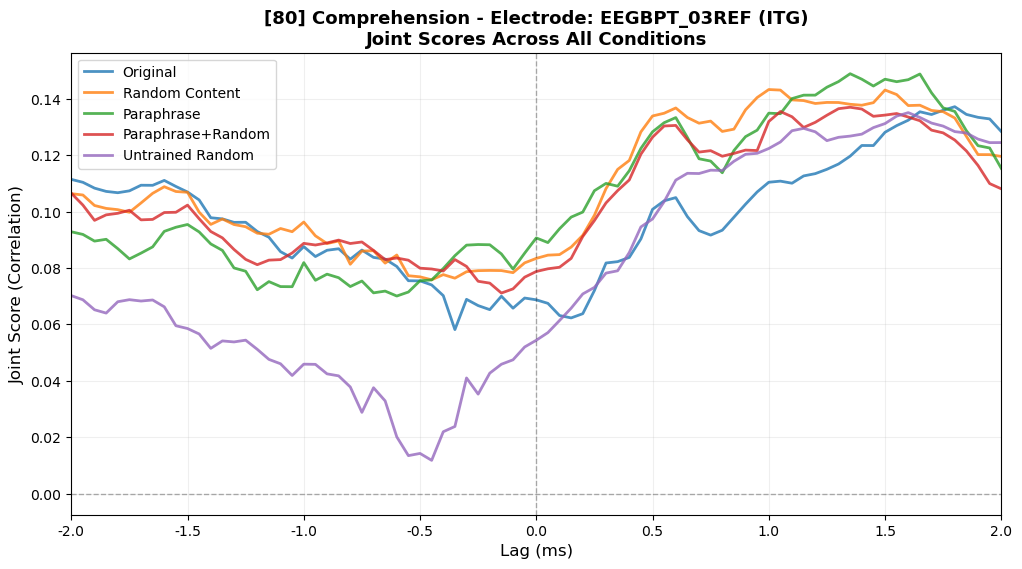

  Saved 80/316 plots...
  Saved 90/316 plots...


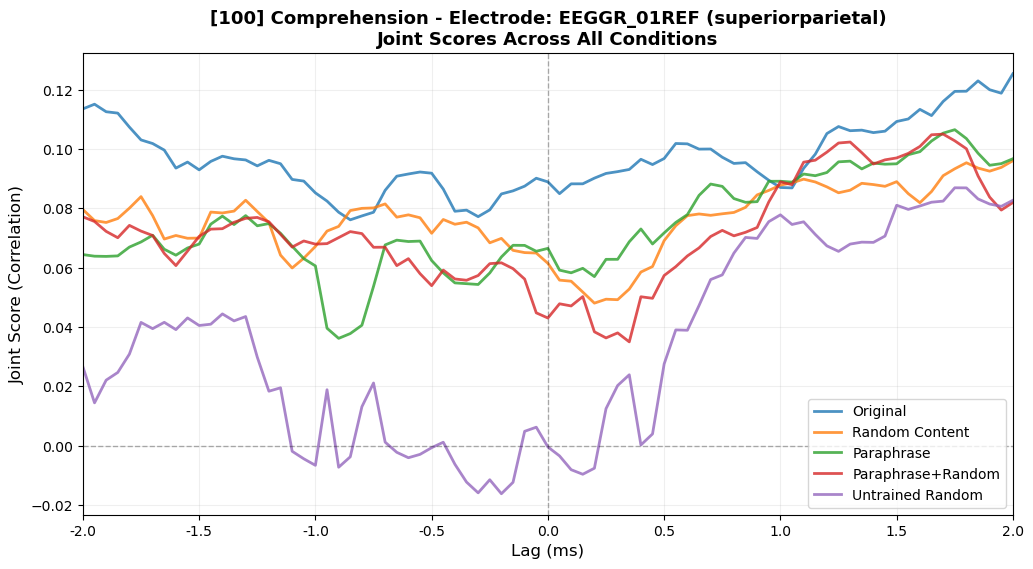

  Saved 100/316 plots...
  Saved 110/316 plots...


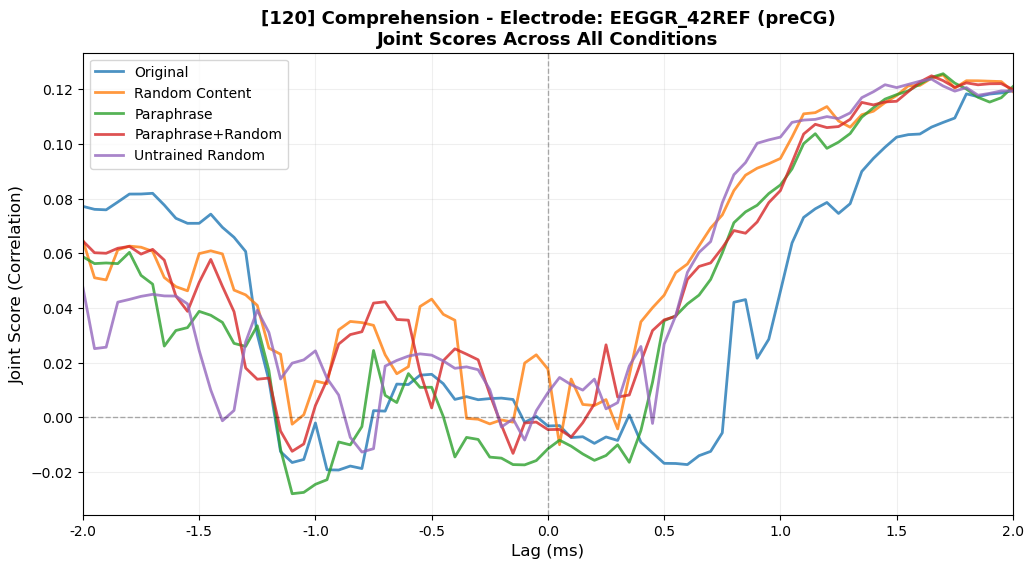

  Saved 120/316 plots...
  Saved 130/316 plots...


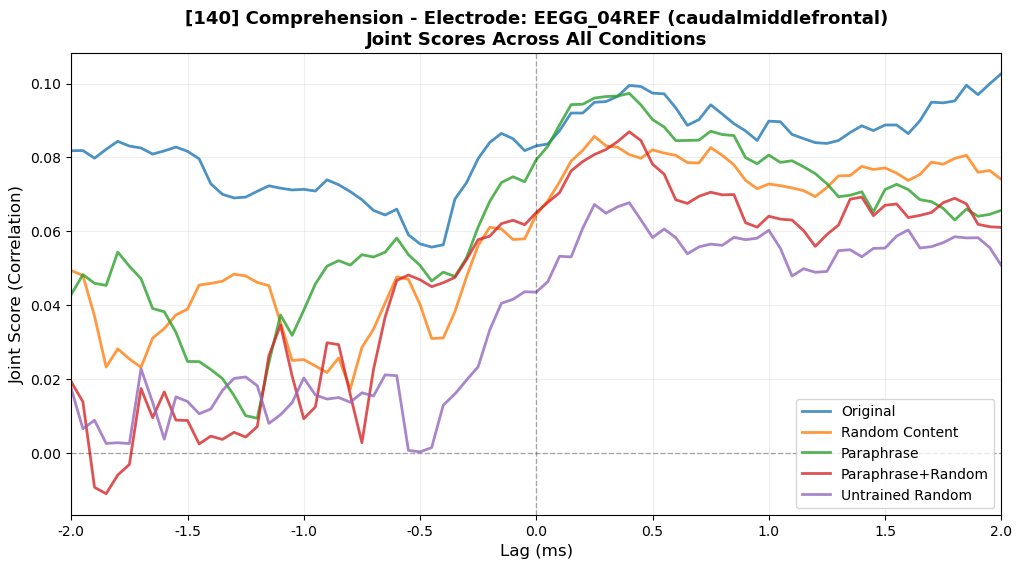

  Saved 140/316 plots...
  Saved 150/316 plots...


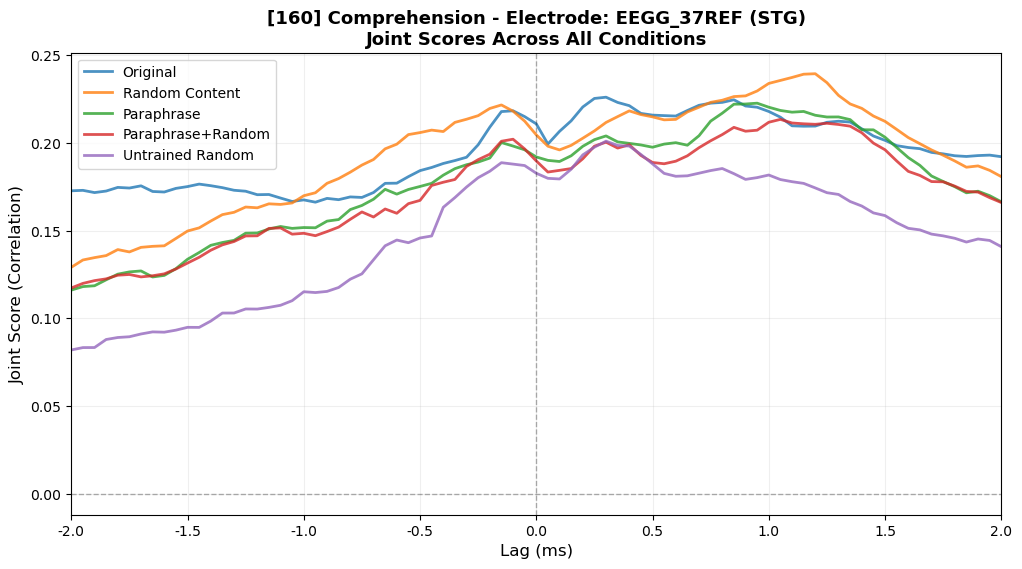

  Saved 160/316 plots...
  Saved 170/316 plots...


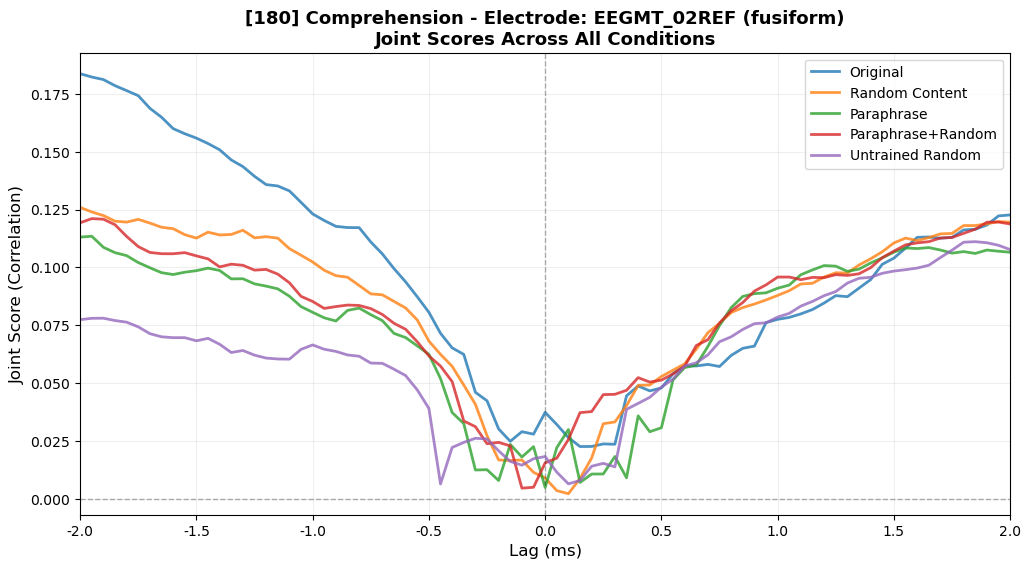

  Saved 180/316 plots...
  Saved 190/316 plots...


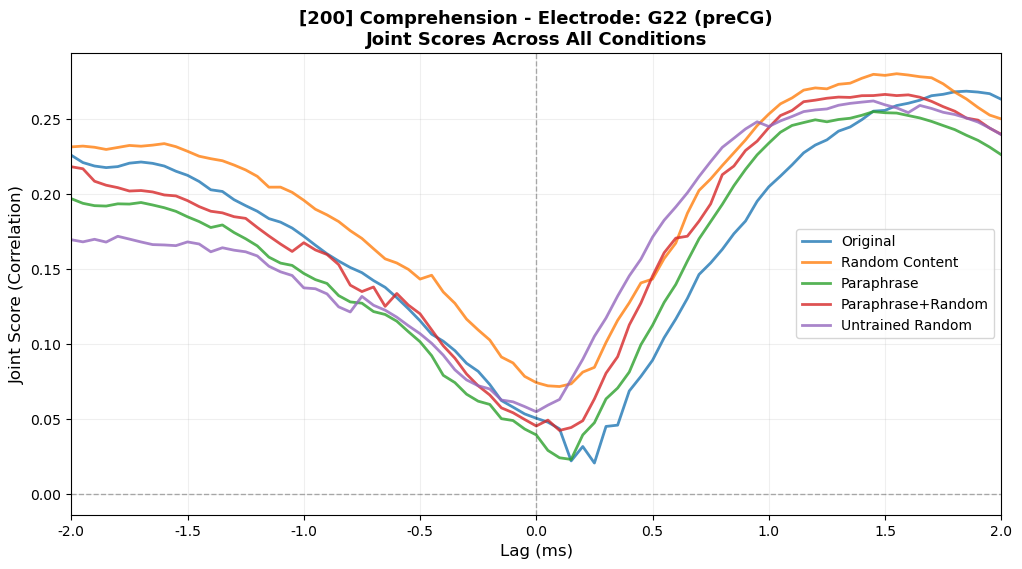

  Saved 200/316 plots...
  Saved 210/316 plots...


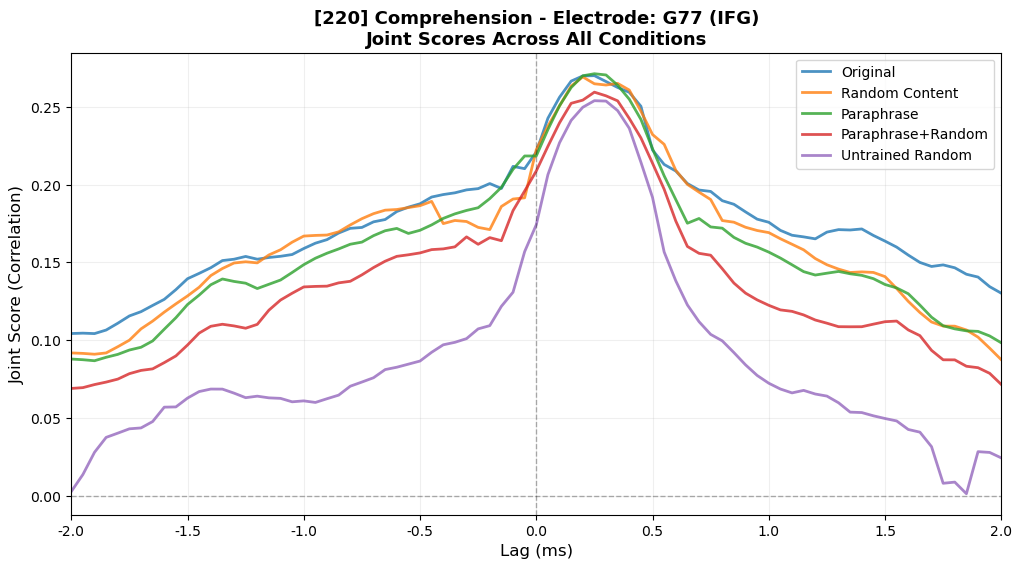

  Saved 220/316 plots...
  Saved 230/316 plots...


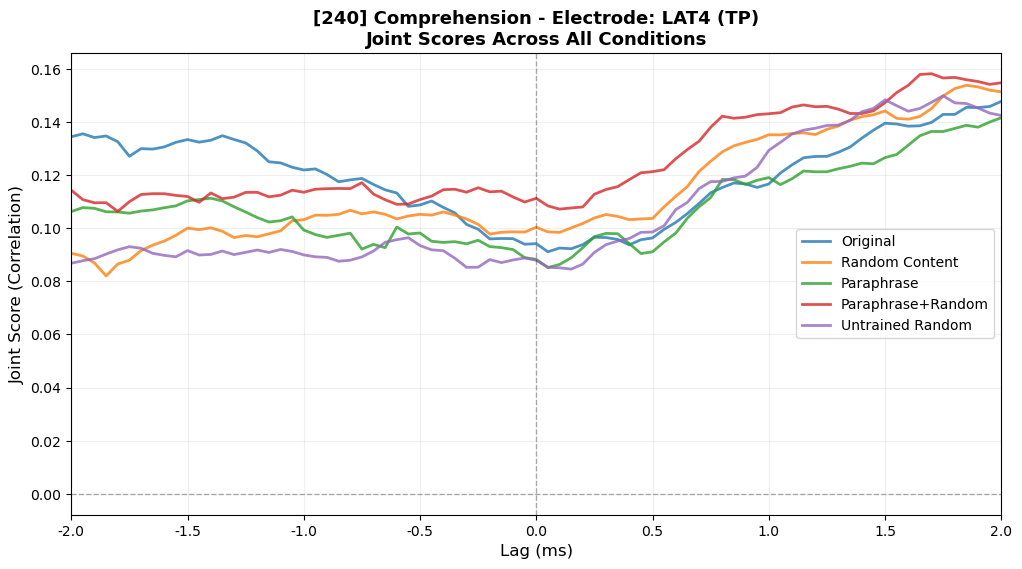

  Saved 240/316 plots...
  Saved 250/316 plots...


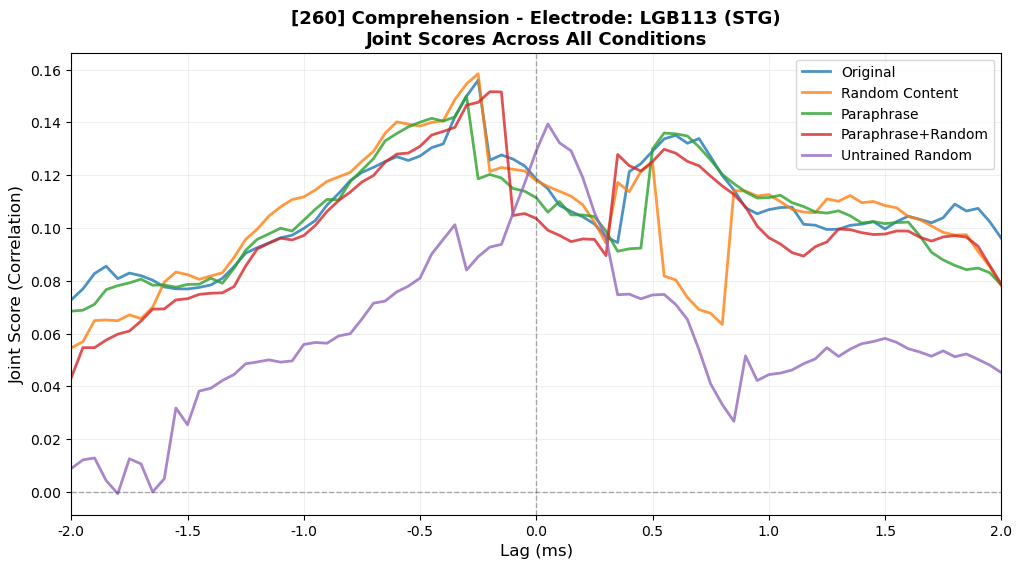

  Saved 260/316 plots...
  Saved 270/316 plots...


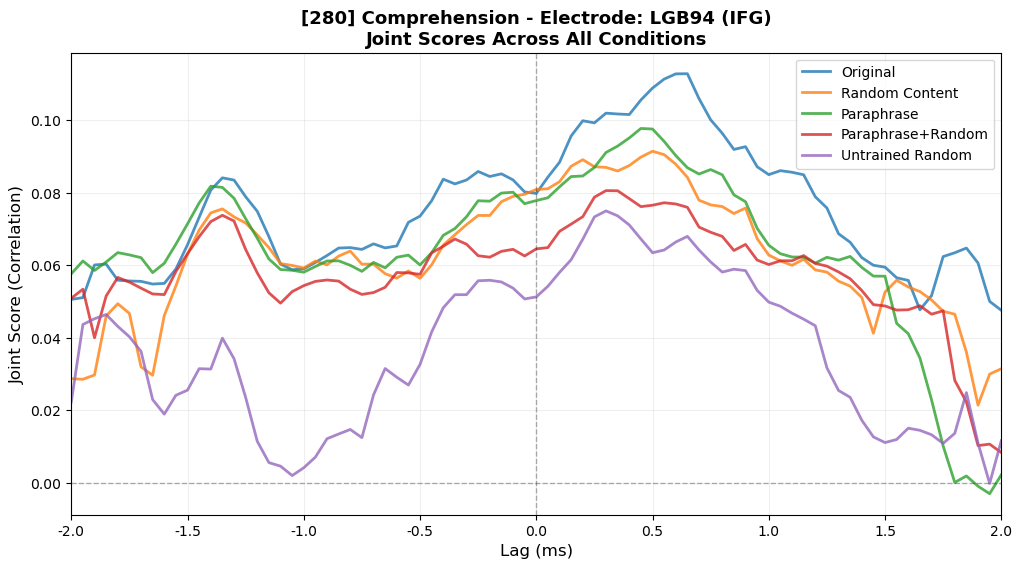

  Saved 280/316 plots...
  Saved 290/316 plots...


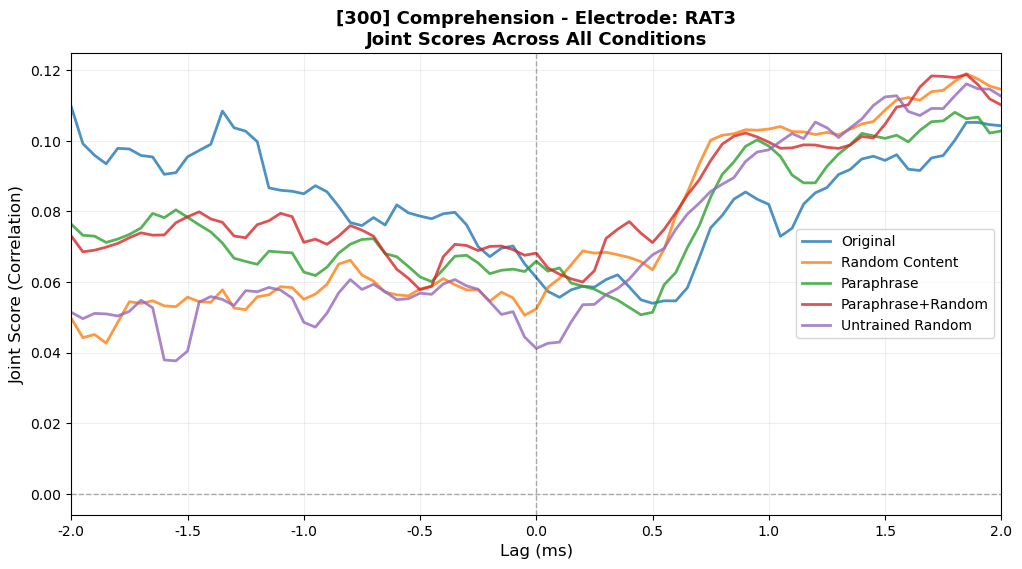

  Saved 300/316 plots...
  Saved 310/316 plots...
Comprehension PDF saved!

Plotting 296 production electrodes to PDF...
  Saved 10/296 plots...


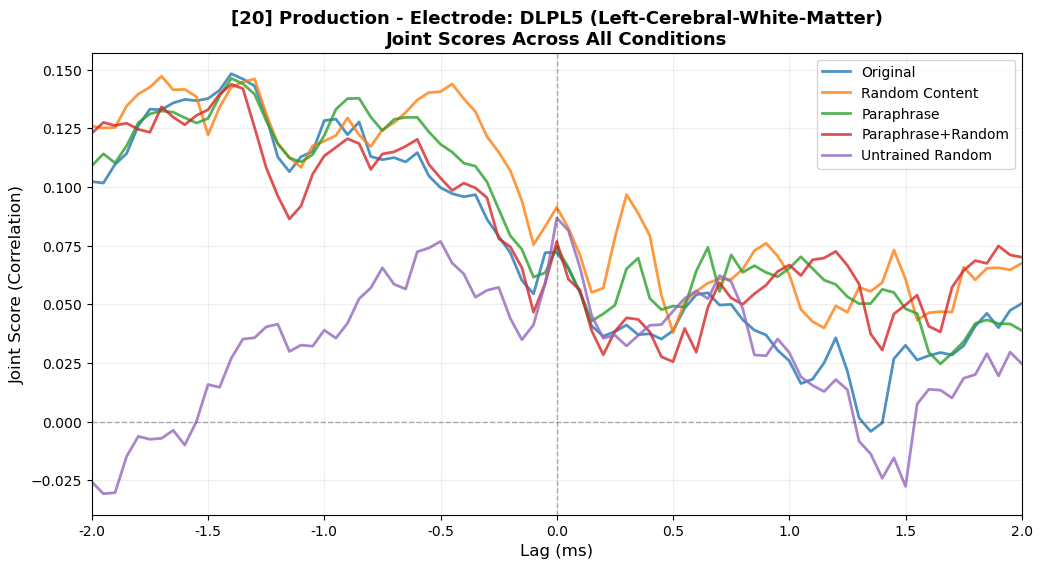

  Saved 20/296 plots...
  Saved 30/296 plots...


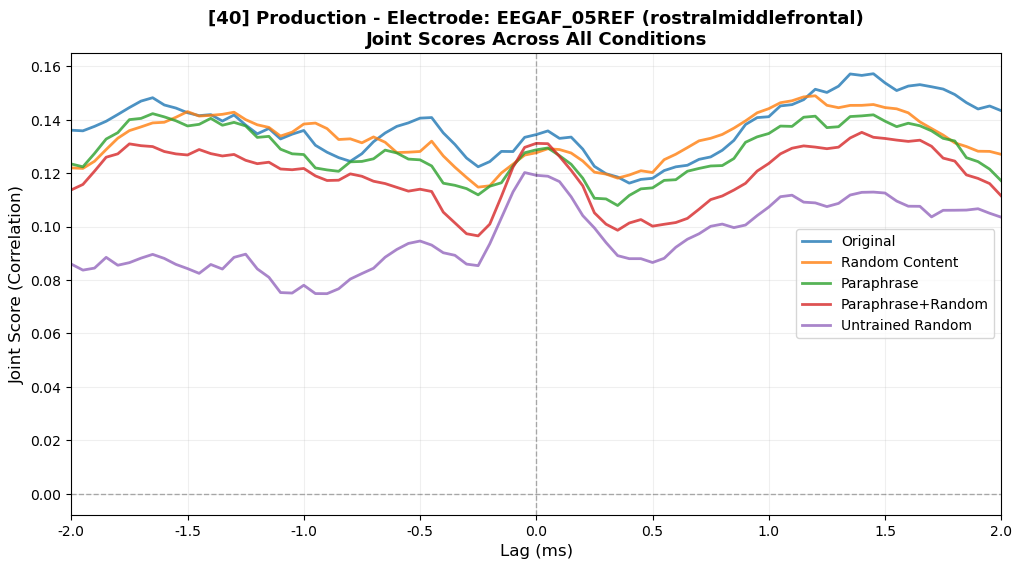

  Saved 40/296 plots...
  Saved 50/296 plots...


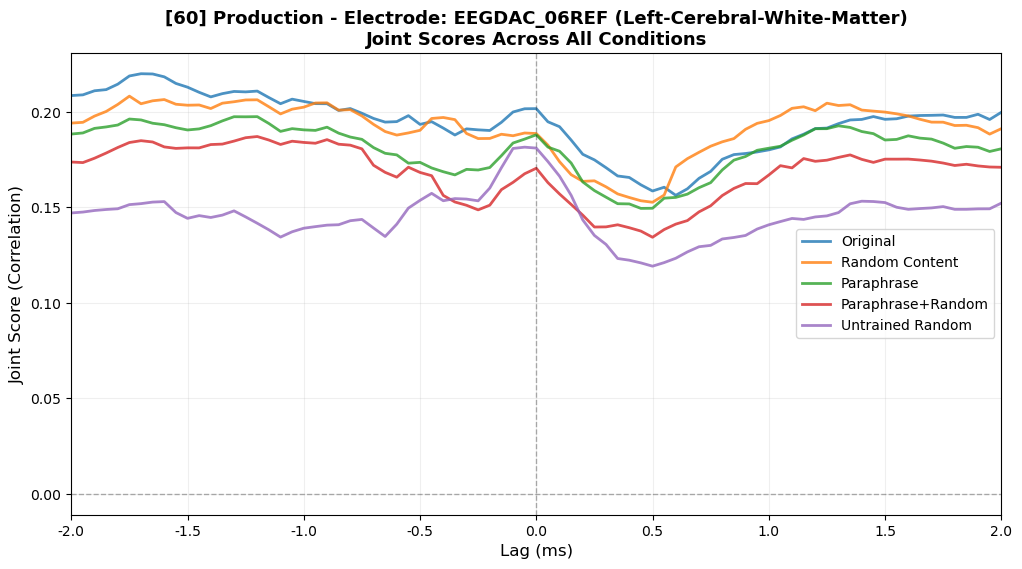

  Saved 60/296 plots...
  Saved 70/296 plots...


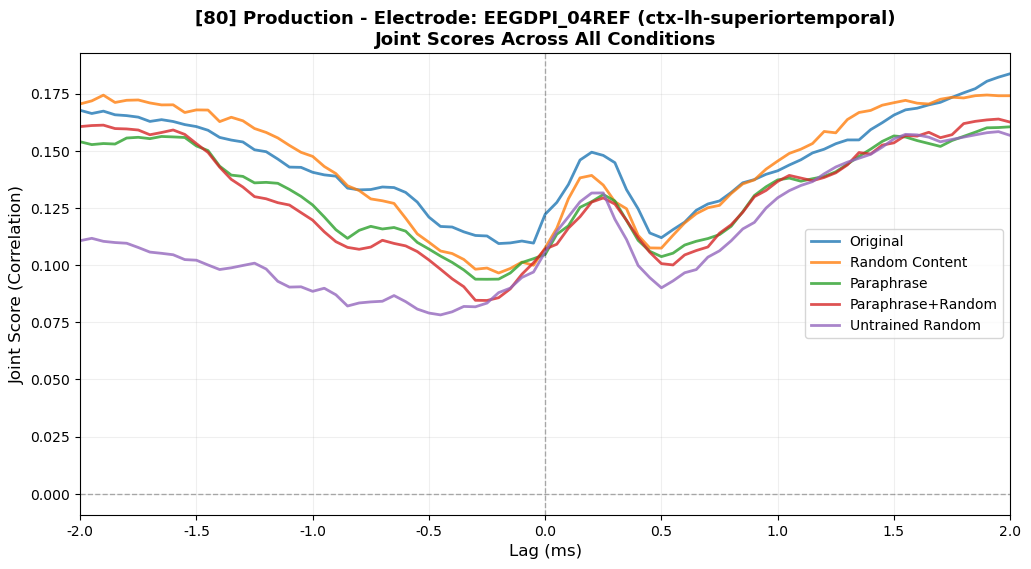

  Saved 80/296 plots...
  Saved 90/296 plots...


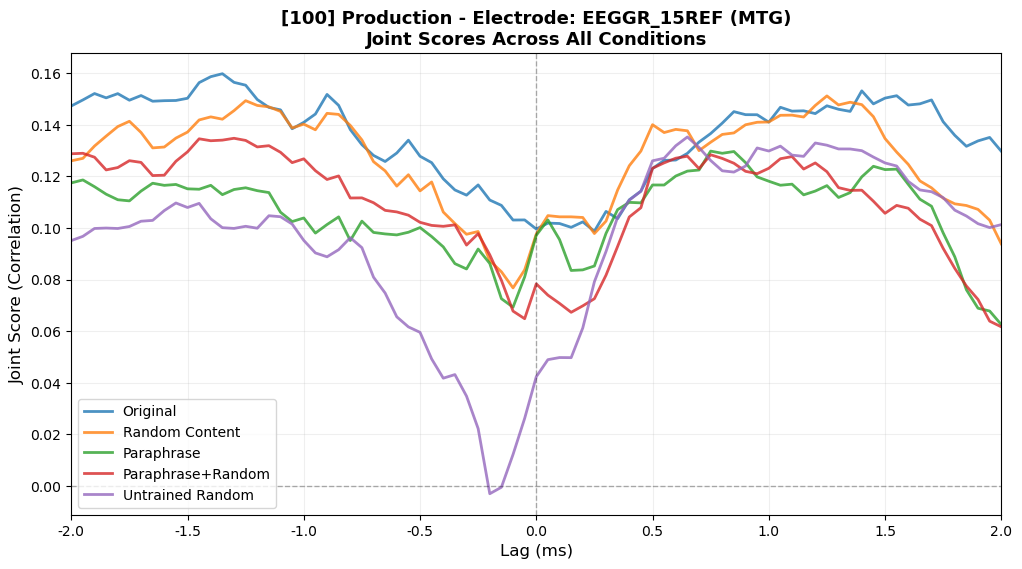

  Saved 100/296 plots...
  Saved 110/296 plots...


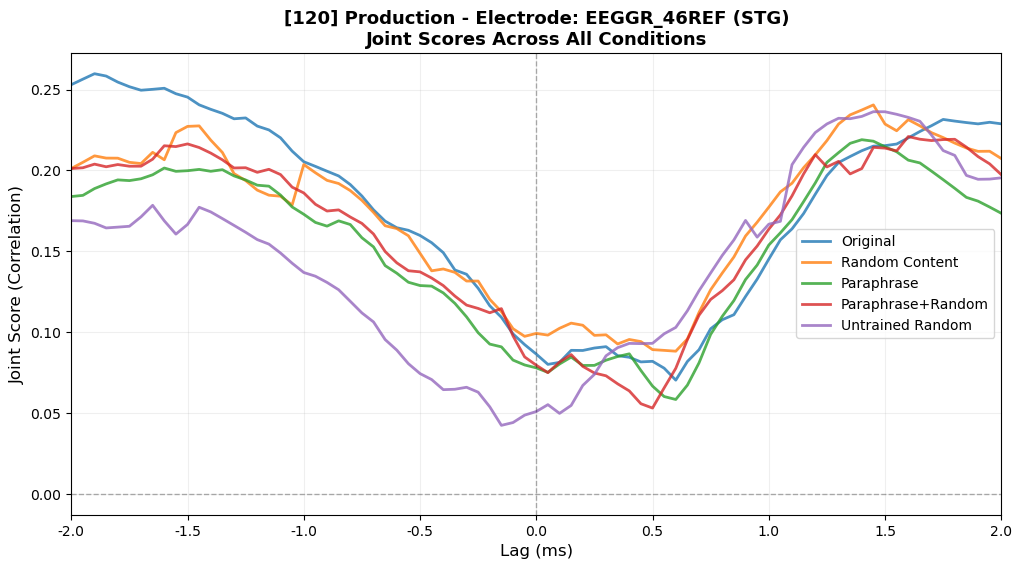

  Saved 120/296 plots...
  Saved 130/296 plots...


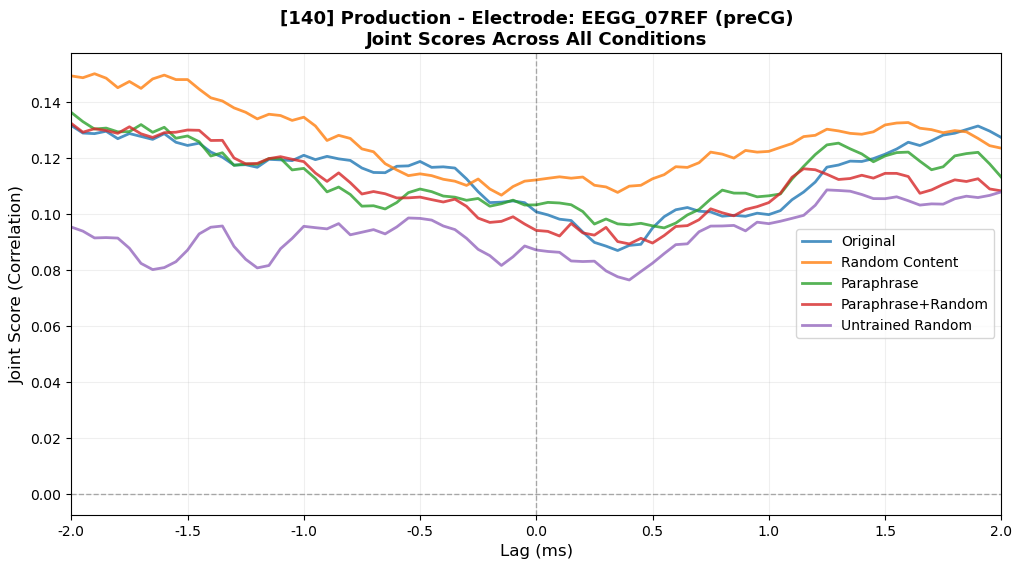

  Saved 140/296 plots...
  Saved 150/296 plots...


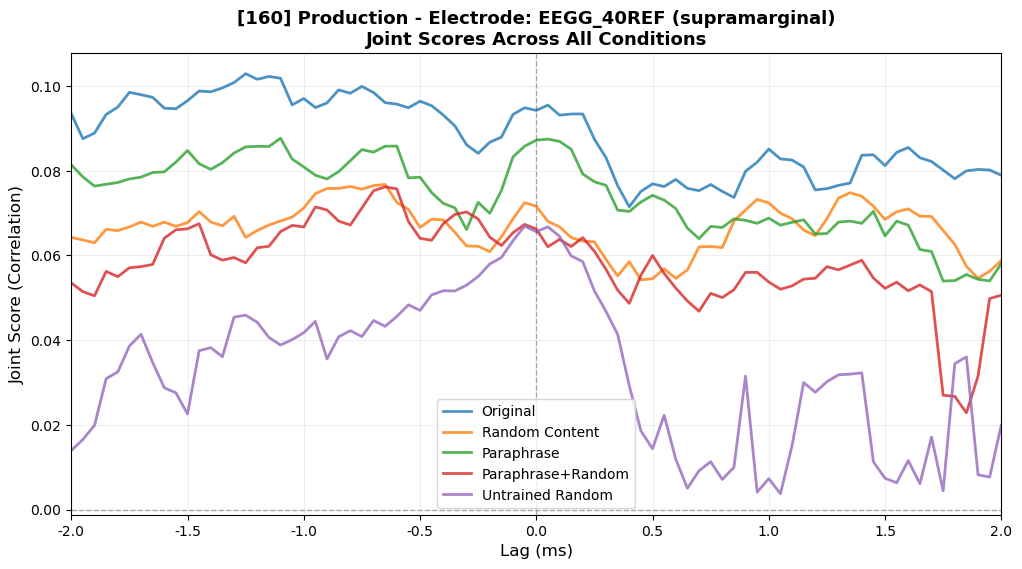

  Saved 160/296 plots...
  Saved 170/296 plots...


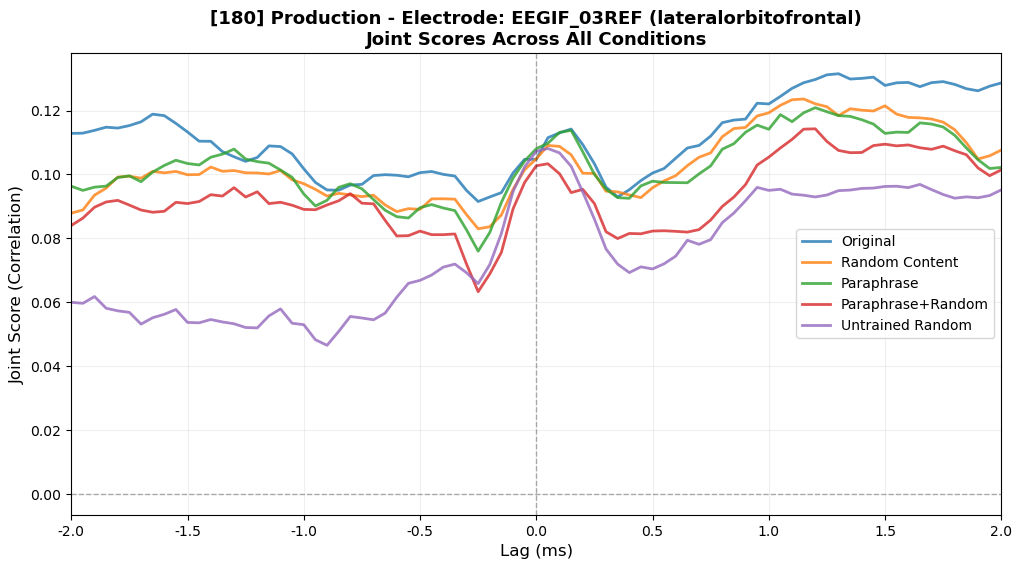

  Saved 180/296 plots...
  Saved 190/296 plots...


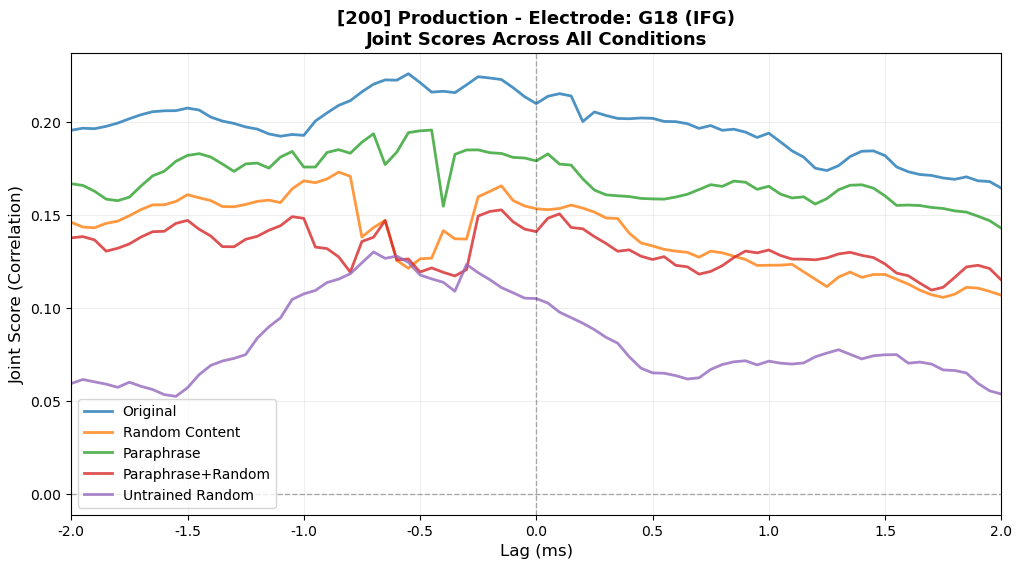

  Saved 200/296 plots...
  Saved 210/296 plots...


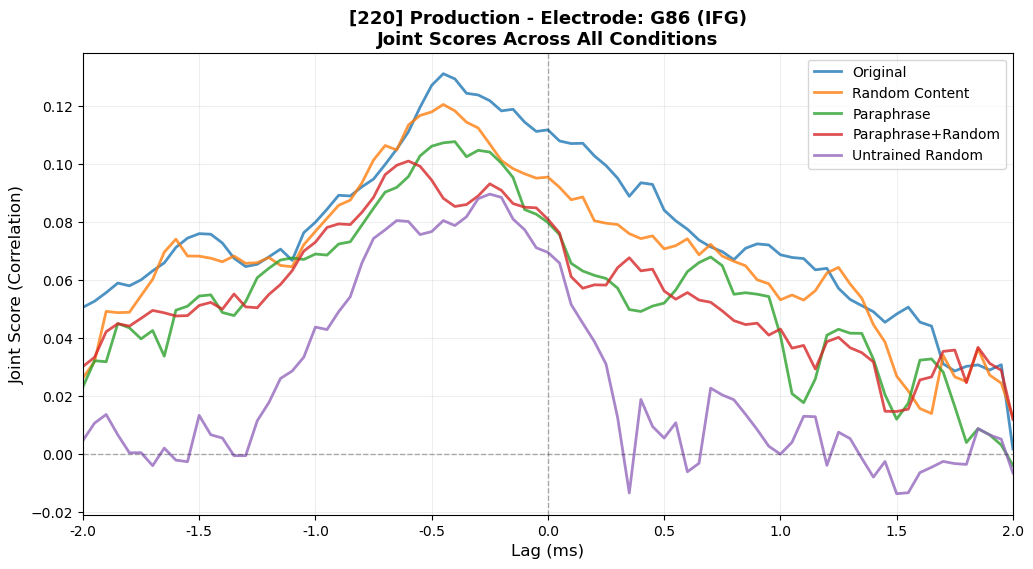

  Saved 220/296 plots...
  Saved 230/296 plots...


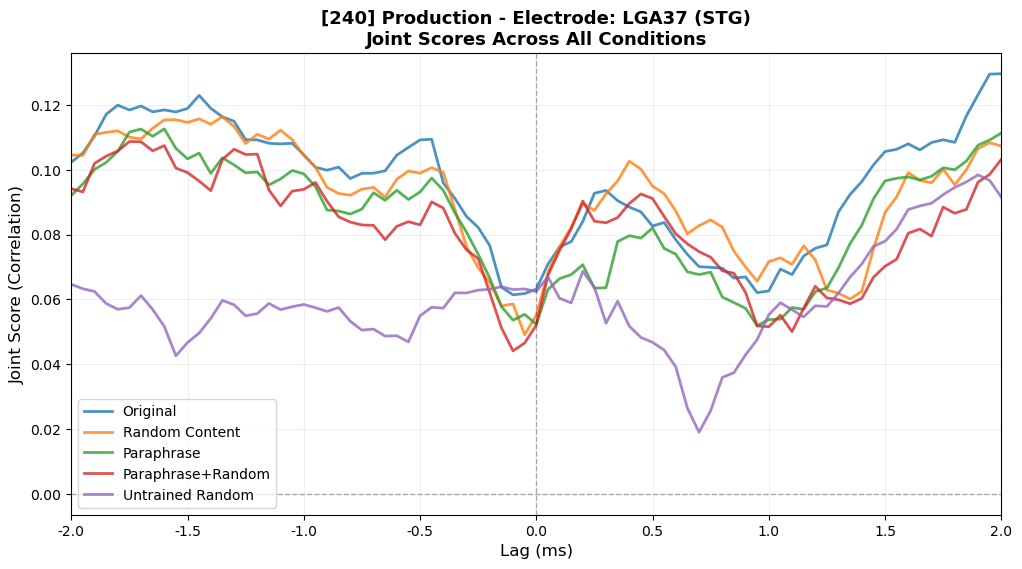

  Saved 240/296 plots...
  Saved 250/296 plots...


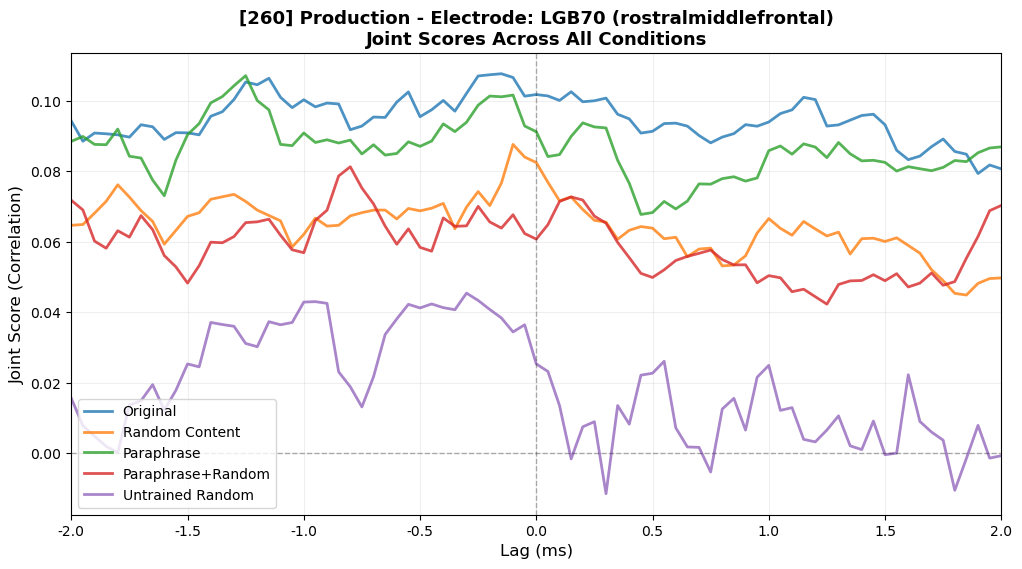

  Saved 260/296 plots...
  Saved 270/296 plots...


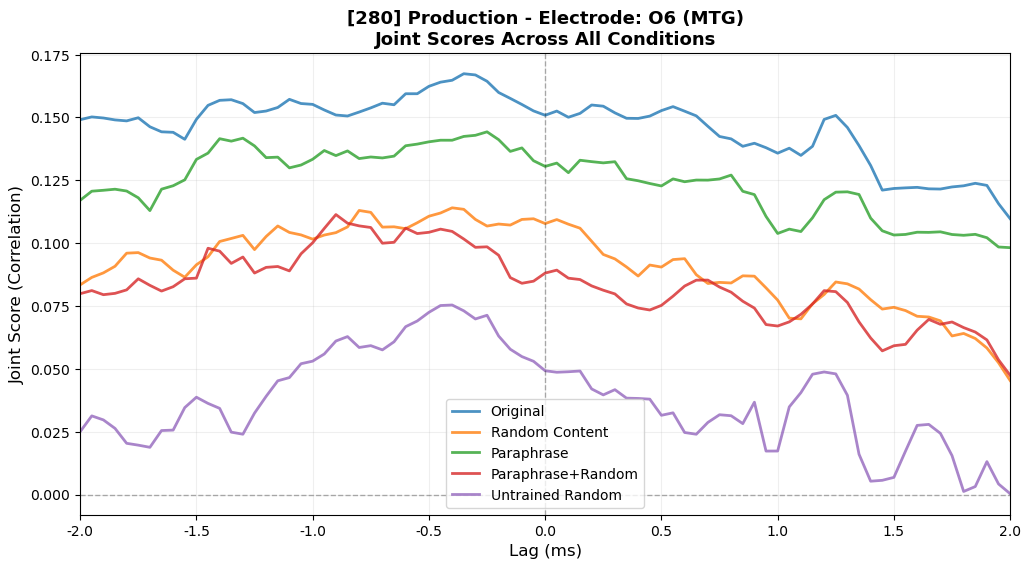

  Saved 280/296 plots...
  Saved 290/296 plots...
Production PDF saved!


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

def plot_electrode_joint_scores_all_conditions(subject_electrode, condition_dfs, condition_names, 
                                                electrode_subjects, lag_range, mode="comp", 
                                                plot_num=None, ax=None):
    """
    Plot joint scores for a single electrode (or subject+electrode pair) across all conditions.
    subject_electrode: tuple (subject, electrode)
    electrode_subjects: dict mapping electrode names to list of subjects
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    else:
        fig = ax.get_figure()
    
    subject, electrode = subject_electrode
    
    # Determine if this is a multi-subject electrode
    is_multi_subject = len(electrode_subjects.get(electrode, [])) > 1
    
    # Define colors for each condition
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    # Plot each condition
    roi = None
    for i, (df, name) in enumerate(zip(condition_dfs, condition_names)):
        # Filter to this specific subject+electrode combination
        elec_data = df[(df['subject'] == subject) & 
                       (df['electrode'] == electrode) & 
                       (df['label3'] == 'joint')]
        
        if elec_data.empty:
            continue
        
        # Take first row if multiple exist
        if len(elec_data) > 1:
            elec_data = elec_data.iloc[[0]]
        
        # Get ROI for title
        if roi is None and 'roi' in elec_data.columns:
            roi = elec_data['roi'].iloc[0]
        
        # Extract joint scores across lags - filter by column names
        lag_cols = [col for col in elec_data.columns 
                    if col not in ['subject', 'electrode', 'label3', 'label1', 'roi']]
        scores = elec_data[lag_cols].values.flatten()
        
        # Use the lag_range parameter for x-axis (NOT column names)
        # Column names are just indices, lag_range has the actual lag values
        actual_lags = lag_range[:len(scores)]
        
        # Plot
        ax.plot(actual_lags, scores, 
                color=colors[i], label=name, lw=2, alpha=0.8)
    
    # Formatting
    ax.axhline(0, ls='dashed', alpha=0.3, c='k', lw=1)
    ax.axvline(0, ls='dashed', alpha=0.3, c='k', lw=1)
    ax.set_xlabel('Lag (ms)', fontsize=12)
    ax.set_ylabel('Joint Score (Correlation)', fontsize=12)
    ax.set_xlim(-2000, 2000)
    ax.set_xticks(np.arange(-2000, 2001, 500))
    ax.set_xticklabels(np.arange(-2, 2.001, 0.5))
    ax.legend(loc='best', frameon=True, fontsize=10)
    ax.grid(True, alpha=0.2)
    
    mode_full = "Comprehension" if mode == "comp" else "Production"
    roi_str = f" ({roi})" if roi else ""
    plot_num_str = f"[{plot_num}] " if plot_num is not None else ""
    
    # Title: show subject only if multi-subject electrode
    if is_multi_subject:
        title_text = f'{plot_num_str}{mode_full} - Subject: {subject}, Electrode: {electrode}{roi_str}'
    else:
        title_text = f'{plot_num_str}{mode_full} - Electrode: {electrode}{roi_str}'
    
    ax.set_title(f'{title_text}\nJoint Scores Across All Conditions', 
                 fontsize=13, fontweight='bold')
    
    return fig

# Prepare condition lists
conditions_c = [original8_c, random_content_word8_c, paraphrase8_c, parandom8_c, untr_reph_c8]
conditions_p = [original8_p, random_content_word8_p, paraphrase8_p, parandom8_p, untr_reph_p8]
condition_names = ["Original", "Random Content", "Paraphrase", "Paraphrase+Random", "Untrained Random"]

# Lag range
lag_range = np.arange(-2000, 2001, 50)

# Save ALL comprehension electrodes to PDF
print(f"Plotting {len(plotting_list_c)} comprehension electrodes to PDF...")
with PdfPages('/scratch/gpfs/HASSON/gidon/247-plotting/results/figures/comprehension_electrodes_all_conditions.pdf') as pdf:
    for idx, subject_electrode in enumerate(plotting_list_c, 1):
        fig = plot_electrode_joint_scores_all_conditions(
            subject_electrode, conditions_c, condition_names, electrode_subjects_c,
            lag_range, mode="comp", plot_num=idx
        )
        pdf.savefig(fig, bbox_inches='tight')
        
        # Display every 20th plot inline
        if idx % 20 == 0:
            plt.show()
        else:
            plt.close(fig)
            
        if idx % 10 == 0:
            print(f"  Saved {idx}/{len(plotting_list_c)} plots...")
print(f"Comprehension PDF saved!")

# Save ALL production electrodes to PDF
print(f"\nPlotting {len(plotting_list_p)} production electrodes to PDF...")
with PdfPages('/scratch/gpfs/HASSON/gidon/247-plotting/results/figures/production_electrodes_all_conditions.pdf') as pdf:
    for idx, subject_electrode in enumerate(plotting_list_p, 1):
        fig = plot_electrode_joint_scores_all_conditions(
            subject_electrode, conditions_p, condition_names, electrode_subjects_p,
            lag_range, mode="prod", plot_num=idx
        )
        pdf.savefig(fig, bbox_inches='tight')
        
        # Display every 20th plot inline
        if idx % 20 == 0:
            plt.show()
        else:
            plt.close(fig)
            
        if idx % 10 == 0:
            print(f"  Saved {idx}/{len(plotting_list_p)} plots...")
print(f"Production PDF saved!")